Found local copy...
Loading...
Done!


         Drug_ID                                               Drug      Y
0   CHEMBL203059       O=C(Nc1cc(-c2ccnc(Nc3ccccc3)c2)ccn1)C1CCOCC1  12.59
1  CHEMBL1900528  C[N+]1(C)[C@H]2C[C@H](OC(=O)C(O)(c3cccs3)c3ccc...   3.00
2  CHEMBL1689128  C[C@H]1CN(Cc2cc(Cl)ccc2OCC(=O)O)CCN1C(=O)Cc1cc...   3.00
3  CHEMBL1917432   Cc1c(Sc2ccc(Cl)cc2)c2c(S(C)(=O)=O)cccc2n1CC(=O)O   3.00
4  CHEMBL1782167      Cc1ccc(C(=O)NC2CC2)cc1-c1ccc(C(=O)NCC2CC2)nc1   3.00
5  CHEMBL1947157  O=c1[nH]c2c(O)ccc([C@@H](O)CNCCc3cccc(CNCCc4c(...  63.00
6  CHEMBL2347404  Fc1cccc(COc2ccc(Nc3ncnc4ccc(-c5cccc(N6CCOCC6)c...  63.10
7  CHEMBL2031559  O=C(Nc1cccc(-c2nnn[nH]2)c1)c1cc(C(F)(F)F)cc2[n...   4.47
8   CHEMBL214350  Cc1ccc2c(c1)c(-c1ccnc3c(C(F)(F)F)cccc13)c(C)n2...   5.60
9       CHEMBL12                CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21   5.75
RMSE: 40.442072048750454, R2: 0.1318381735045221
Model and results saved!


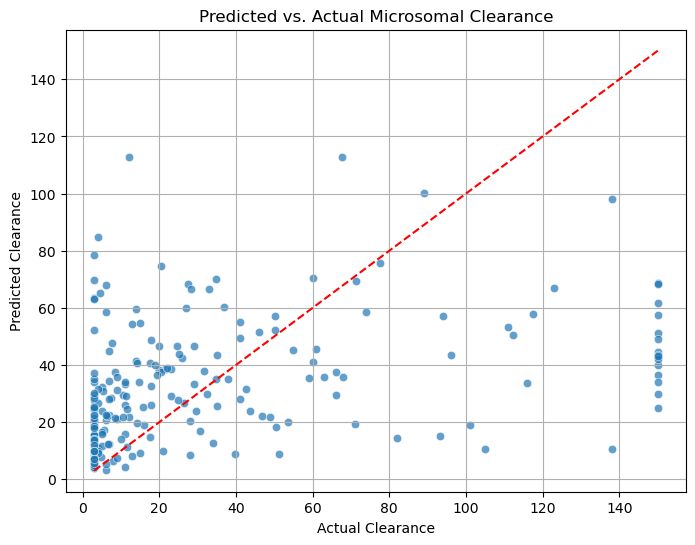

In [13]:
import numpy as np
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import matplotlib.pyplot as plt
import seaborn as sns



mol = Chem.MolFromSmiles("O=C(C[C@@H](N(C(C(C=C1)=CC(Cl)=C1C2=C(OCC3=CC=CC=C3)C=CC(C(F)(F)F)=C2)=O)[H])C(NCC4=CN(CC(OC5=CC=C(F)C=C5)=O)N=N4)=O)OC(C)(C)C")
img = Draw.MolToImage(mol)
img.show()



# 2. Load and Preprocess Data
from tdc.single_pred import ADME
data = ADME(name = 'Clearance_Microsome_AZ')
df = data.get_data()
print(df.head(10))



# 3. Feature extraction using RDKit molecular descriptors
def featurize(smiles_list):
    features = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            generator = GetMorganGenerator(radius=2, fpSize=1024)
            fp = generator.GetFingerprint(mol)
            features.append(fp)
        else:
            features.append(np.zeros(1024))
    return np.array(features)



# Prepare data
X = featurize(df['Drug'])
y = df['Y']



# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize (ONLY for descriptors, NOT for Morgan fingerprints)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit + transform training data
X_test_scaled = scaler.transform(X_test)  # Transform test data

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}, R2: {r2}")

# Save model
joblib.dump(model, "mouse_liver_model.pkl")

# Uncertainty Estimation using Model Variance (Simple Example)
def predict_with_uncertainty(forest, X, n_estimators=100):
    preds = np.array([tree.predict(X) for tree in forest.estimators_])
    return preds.mean(axis=0), preds.std(axis=0)

mean_pred, uncertainty = predict_with_uncertainty(model, X_test_scaled)

# Save results
results = pd.DataFrame({"True": y_test, "Pred": mean_pred, "Uncertainty": uncertainty})
results.to_csv("predictions_with_uncertainty.csv", index=False)

print("Model and results saved!")

# Create scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=mean_pred, alpha=0.7)

# Add a diagonal reference line (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

# Labels and title
plt.xlabel("Actual Clearance")
plt.ylabel("Predicted Clearance")
plt.title("Predicted vs. Actual Microsomal Clearance")
plt.grid(True)

# Show the plot
plt.show()




